In [18]:
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

In [12]:
#LOAD_DATA
df = pd.read_csv("diabetes.csv")

In [13]:
#Polynomial Regression requires one independent variable for plotting
#Change these as per your dataset
X = df[["Age"]]
y = df["Glucose"]

In [14]:
#Train_Test_Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [ ]:

# Polynomial Features Transformation

poly = PolynomialFeatures(degree=2) # changfe degree if needed
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [15]:
#Train_Model
model = LinearRegression()
model.fit(X_train_poly, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [17]:
#Predictions
y_pred = model.predict(X_test_poly)
print(y_pred[:5])

[130.38201572 109.91424938 109.91424938 123.35236729 134.56340711]


In [ ]:
#Metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [ ]:
#Polynomial Regression

print("\nCoefficients:", model.coef_)
print("Intercept:", model.intercept_)


Coefficients: [ 0.          1.6652747  -0.01148315]
Intercept: 80.00755039304403


<function print(*args, sep=' ', end='\n', file=None, flush=False)>

In [10]:
print("\nMean Squared Error:", mse)
print("R^2 Score:", r2)


Mean Squared Error: 944.8234565706043
R^2 Score: 0.061100053531872645


In [11]:
print("\nFirst 10 predictions: ")
print(y_pred[:10])


First 10 predictions: 
[130.38201572 109.91424938 109.91424938 123.35236729 134.56340711
 136.86112616 111.08574857 131.04825626 125.90228016 139.73409157]


c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


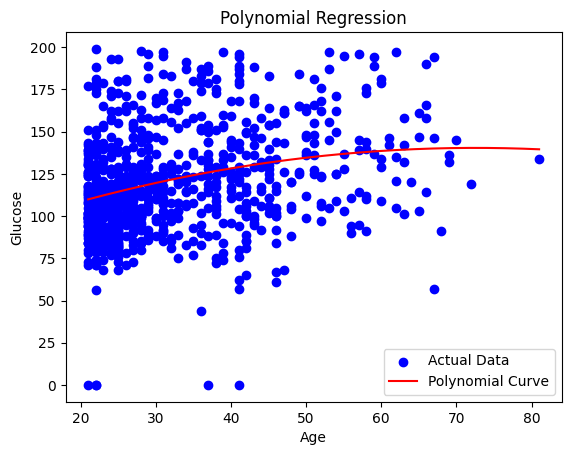

In [23]:
# Graph 
# Creating line for polynomial curve

plt.scatter(X, y, color='blue', label='Actual Data')

X_grid = np.linspace(X.min(), X.max(), 200).reshape(-1,1)
X_grid_poly = poly.transform(X_grid)
y_grid_pred = model.predict(X_grid_poly)

plt.plot(X_grid, y_grid_pred, color='red', label='Polynomial Curve')

plt.xlabel('Age')
plt.ylabel('Glucose')
plt.title('Polynomial Regression')
plt.legend()
plt.show()